# Fig. 11. RF-CRATE vs. DWS baselines.

/tmp/ipykernel_3929954/2415741560.py:59: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0, 100)


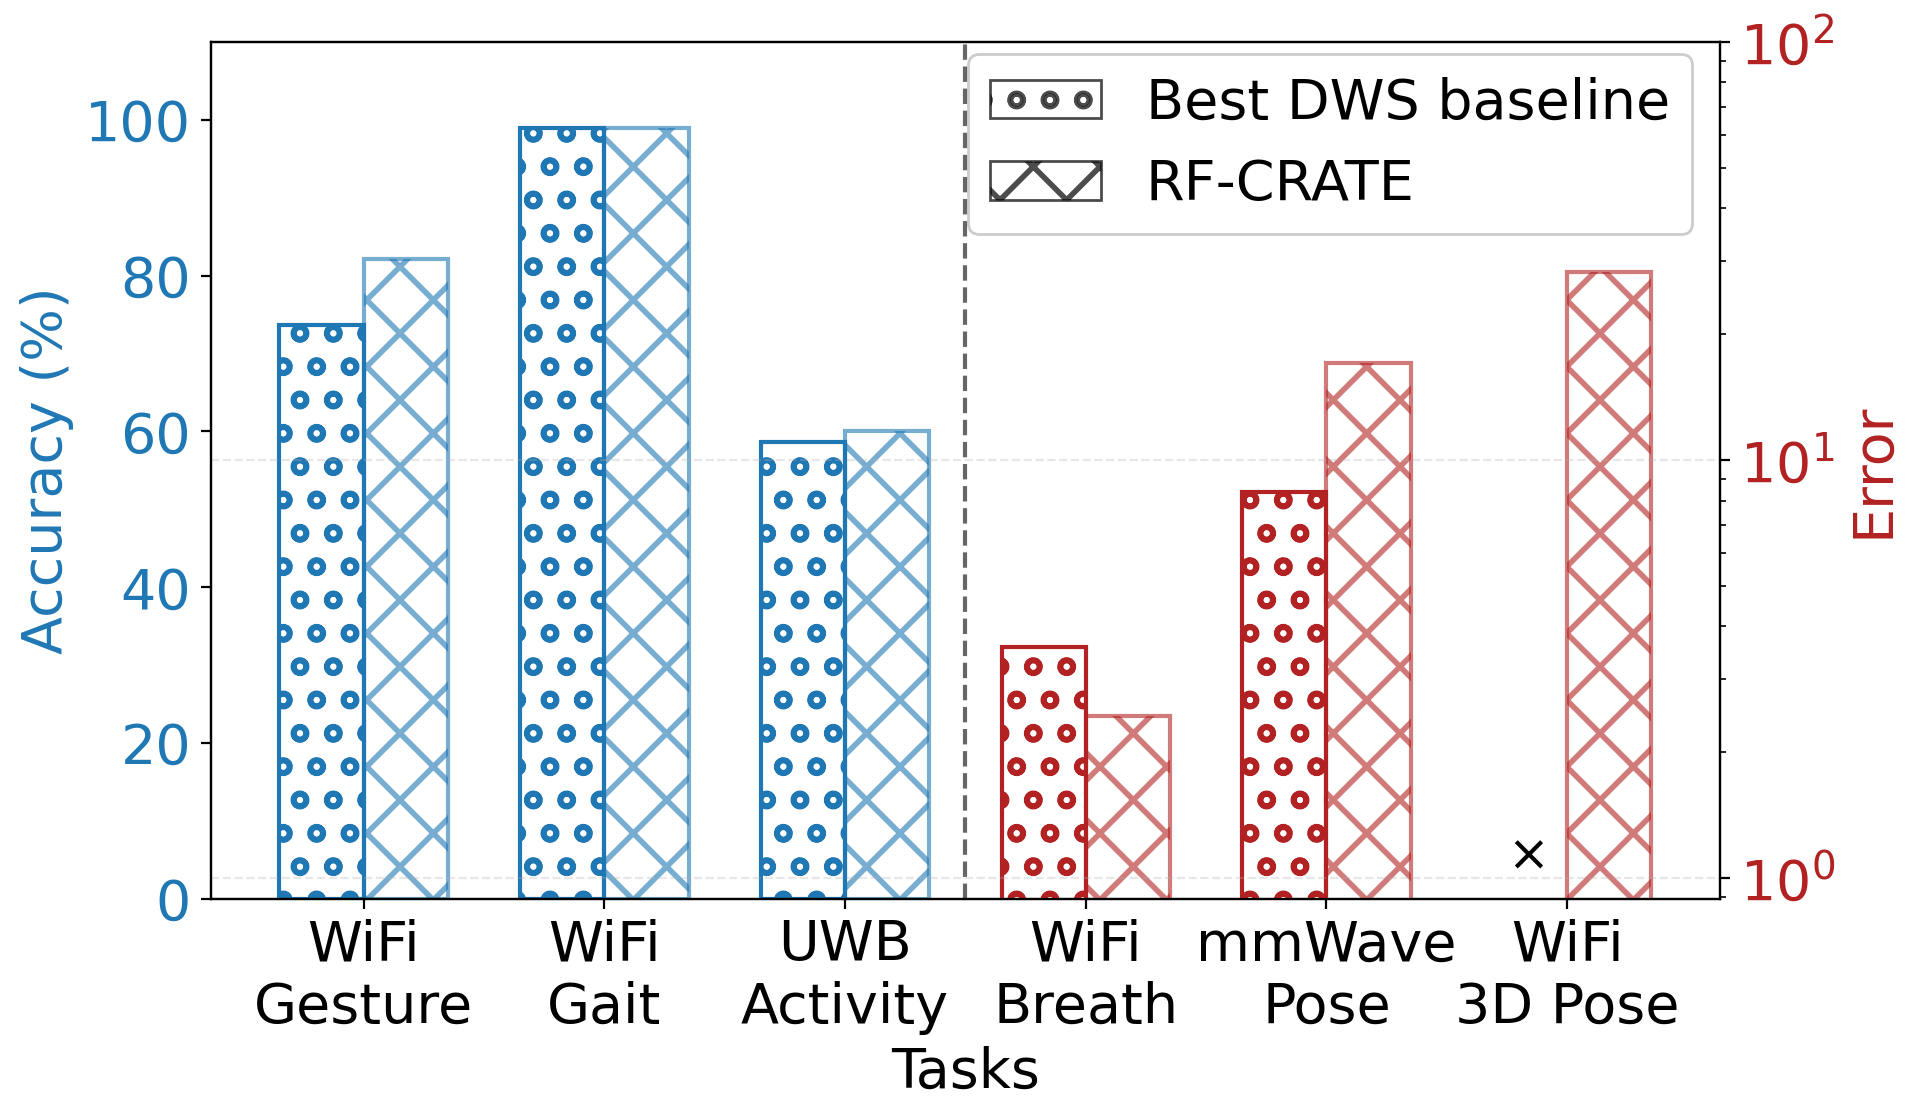

In [2]:
# Results in Table 1: 
# we compare the RF-CRATE to other DWS baselines (selecting the best perfromance one for each task)

tasks = [
    'WiFi Gesture',
    'WiFi Gait',
    'UWB Activity',
    
    
    'WiFi Breath',
    'mmWave Pose',
    'WiFi 3D Pose',
]

Best_DWS_Performance = {
    'WiFi Gesture': {'acc':73.67 , 'std': 13.11, 'method': 'SLNet'},
    'WiFi Gait': {'acc': 99.00 , 'std': 1.88, 'method': 'RF-Net'},
    'UWB Activity': {'acc': 58.59, 'std': 7.59, 'method': 'STFNets'},
    
   
    'WiFi Breath': {'error': 3.57, 'std': 0.98, 'method': 'RF-Net'},
    'mmWave Pose': {'error': 8.37, 'std': 5.91, 'method': 'RF-Net'},
    'WiFi 3D Pose': {'error': None, 'std': None, 'method': 'No model suitable for this task'},
}

RF_CRATE_Performance = {
    'WiFi Gesture': {'acc': 82.10, 'std': 10.41, 'method': 'RF-CRATE'},
    'WiFi Gait': {'acc': 98.98, 'std': 1.91, 'method': 'RF-CRATE'},
    'UWB Activity': {'acc': 60.07, 'std': 10.41, 'method': 'RF-CRATE'},
    
    
    'WiFi Breath': {'error': 2.44, 'std': 0.83, 'method': 'RF-CRATE'},
    'mmWave Pose': {'error': 17.09, 'std': 9.13, 'method': 'RF-CRATE'},
    'WiFi 3D Pose': {'error': 28.12, 'std': 27.02, 'method': 'RF-CRATE'},
}

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib as mpl


plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 20})

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

ax1 = plt.gca()
ax1.set_xlabel('Tasks', fontsize=20)
ax1.set_ylabel('Accuracy (%)', fontsize=20, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, 110)  # Appropriate range for accuracy percentage


ax2 = ax1.twinx()
ax2.set_ylabel('Error', fontsize=20, color='firebrick')
ax2.set_yscale('log')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='firebrick')

x = np.arange(len(tasks))
width = 0.35

acc_tasks = tasks[:3]
dws_acc = [Best_DWS_Performance[task]['acc'] for task in acc_tasks]
dws_acc_std = [Best_DWS_Performance[task]['std'] for task in acc_tasks]
rf_crate_acc = [RF_CRATE_Performance[task]['acc'] for task in acc_tasks]
rf_crate_acc_std = [RF_CRATE_Performance[task]['std'] for task in acc_tasks]

# Plot error data (last 3 tasks)
error_tasks = tasks[3:]
dws_error = []
dws_error_std = []
for task in error_tasks:
    if Best_DWS_Performance[task]['error'] is not None:
        dws_error.append(Best_DWS_Performance[task]['error'])
        dws_error_std.append(Best_DWS_Performance[task]['std'])
    else:
        dws_error.append(0)  # Use 0 for plotting but will mark as N/A
        dws_error_std.append(0)

rf_crate_error = [RF_CRATE_Performance[task]['error'] for task in error_tasks]
rf_crate_error_std = [RF_CRATE_Performance[task]['std'] for task in error_tasks]

mpl.rcParams['hatch.linewidth'] = 0.2
acc_bars1 = ax1.bar(x[:3] - width/2, dws_acc, width,
                   capsize=8, facecolor='none', hatch='o',edgecolor='tab:blue', linewidth=1.5, label='Best DWS (Accuracy)')
acc_bars2 = ax1.bar(x[:3] + width/2, rf_crate_acc, width, 
                    capsize=8, facecolor='none', hatch='X', edgecolor='tab:blue', linewidth=1.5, alpha=0.6)

error_bars1 = ax2.bar(x[3:] - width/2, dws_error, width, 
                     capsize=8, facecolor='none', hatch='o',edgecolor='firebrick', linewidth=1.5, label='Best DWS (Error)')
error_bars2 = ax2.bar(x[3:] + width/2, rf_crate_error, width,
                      capsize=8, facecolor='none', hatch='X', edgecolor='firebrick', linewidth=1.5, alpha=0.6)

ax1.axvline(x=2.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

for i, rect in enumerate(error_bars1):
    height = rect.get_height()
    if Best_DWS_Performance[error_tasks[i]]['error'] is not None:
        pass
    else:
        ax2.text(rect.get_x() + rect.get_width()/2., height + 1,
                '$\\times$', ha='center', va='bottom', fontsize=18)

ax1.set_xticks(x)
task_label = ['WiFi\nGesture', 'WiFi\nGait', 'UWB\nActivity', 'WiFi\nBreath', 'mmWave\nPose', 'WiFi\n3D Pose']
ax1.set_xticklabels(task_label, rotation=0, ha='center', fontsize=20)

plt.xlabel('Tasks', fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)

mpl.rcParams['hatch.linewidth'] = 2
acc_dws_patch = mpatches.Patch(facecolor='none', alpha=0.7, label='Best DWS baseline', hatch='o', edgecolor='black')
acc_rf_patch = mpatches.Patch(facecolor='none', alpha=0.7, label='RF-CRATE', hatch='x', edgecolor='black')
plt.rcParams['hatch.color'] = 'black'  # Set hatch color globally

plt.legend(handles=[acc_dws_patch, acc_rf_patch], 
           loc='upper right', bbox_to_anchor=(1, 1.018), ncol=1, fontsize=20, 
           framealpha=0.2, 
           edgecolor='black',
           )

plt.tight_layout()
# plt.savefig("figures/V2_rf_crate_vs_DWS.pdf", dpi=200, bbox_inches='tight')
plt.show()
